In [ ]:
# ============================================
# Cell 0: Mount Google Drive
# ============================================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [1]:
# ============================================
# Cell 1: Python & Environment Check
# ============================================
import sys
print("Python version:", sys.version.split()[0])


Python version: 3.12.12


In [1]:
# ============================================
# Cell 2: Install Required Packages
# ============================================
!pip install --quiet git+https://github.com/openai/CLIP.git
!pip install --quiet torch torchvision pillow matplotlib pandas tqdm kaggle seaborn scikit-learn


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00


In [4]:
# ============================================
# Cell 3: Check GPU Availability
# ============================================
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("GPU Memory (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))


Torch version: 2.9.0+cu126
CUDA available: True
GPU Name: Tesla T4
GPU Memory (GB): 14.74


In [6]:
# ============================================
# Cell 4: Setup Kaggle API (Optional)
# ============================================
import os
if os.path.exists('/content/kaggle.json'):
    !mkdir -p ~/.kaggle
    !cp /content/kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("kaggle.json installed")
else:
    print("No kaggle.json found. Please upload it to /content if needed.")


kaggle.json installed


In [7]:
# ============================================
# Cell 5: Download and Extract Dataset
# ============================================
!kaggle datasets download paultimothymooney/chest-xray-pneumonia -q
!unzip -q chest-xray-pneumonia.zip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other


In [8]:
# Clean up unnecessary files
!rm -rf /content/chest_xray/__MACOSX
!rm -rf /content/chest_xray/chest_xray

In [9]:
# List dataset structure
!ls /content/chest_xray


test  train  val


In [10]:
# ============================================
# Cell 6: Imports and Basic Setup
# ============================================
import clip
from PIL import Image, ImageEnhance
import random, shutil
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchsummary import summary
import os
import torch
!pip install torchinfo
from torchinfo import summary

In [11]:
# ============================================
# Cell 7: Reproducibility
# ============================================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [12]:
# ============================================
# Cell 8: Inspect Dataset Structure and Counts
# ============================================
base = "/content/chest_xray"
splits = ["train", "val", "test"]
classes = ["NORMAL", "PNEUMONIA"]

for split in splits:
    print(f"\n=== {split} ===")
    split_dir = os.path.join(base, split)
    if not os.path.exists(split_dir):
        print("  NOT FOUND:", split_dir)
        continue
    for cls in sorted(os.listdir(split_dir)):
        cls_dir = os.path.join(split_dir, cls)
        if os.path.isdir(cls_dir):
            count = len([f for f in os.listdir(cls_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))])
            print(f"  {cls}: {count}")



=== train ===
  NORMAL: 1341
  PNEUMONIA: 3875

=== val ===
  NORMAL: 8
  PNEUMONIA: 8

=== test ===
  NORMAL: 234
  PNEUMONIA: 390


In [13]:
# ============================================
# Cell 9: Verify Images (Detect Corrupted Files)
# ============================================
bad_files = []
for root, _, files in os.walk(base):
    for f in files:
        if not f.lower().endswith(('.png','.jpg','.jpeg')):
            continue
        fp = os.path.join(root, f)
        try:
            img = Image.open(fp)
            img.verify()
        except:
            bad_files.append(fp)

print("Bad files found:", len(bad_files))
if bad_files:
    print("Examples:", bad_files[:5])

Bad files found: 0


In [ ]:
# ============================================
# Cell 10: Check Class Balance in Train
# ============================================
train_dir = os.path.join(base, "train")
counts = {cls: len([f for f in os.listdir(os.path.join(train_dir, cls)) if f.lower().endswith(('.png','.jpg','.jpeg'))])
          for cls in os.listdir(train_dir)}
print("Train counts:", counts)
if len(counts) > 1:
    mx, mn = max(counts.values()), min(counts.values())
    print("Ratio max/min:", round(mx/mn, 2))

Train counts: {'NORMAL': 1341, 'PNEUMONIA': 3875}
Ratio max/min: 2.89


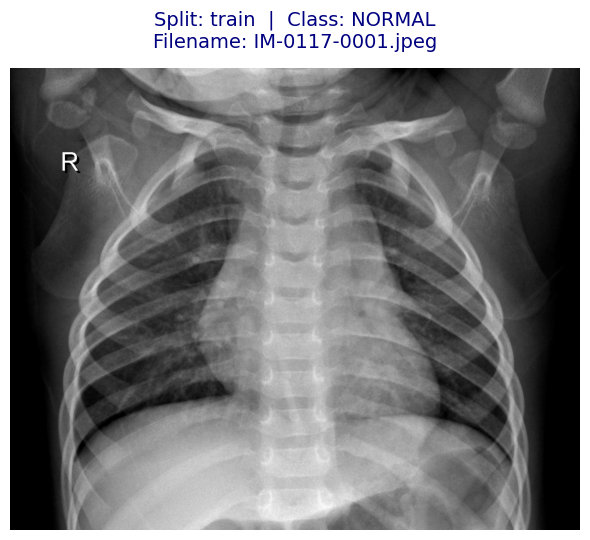

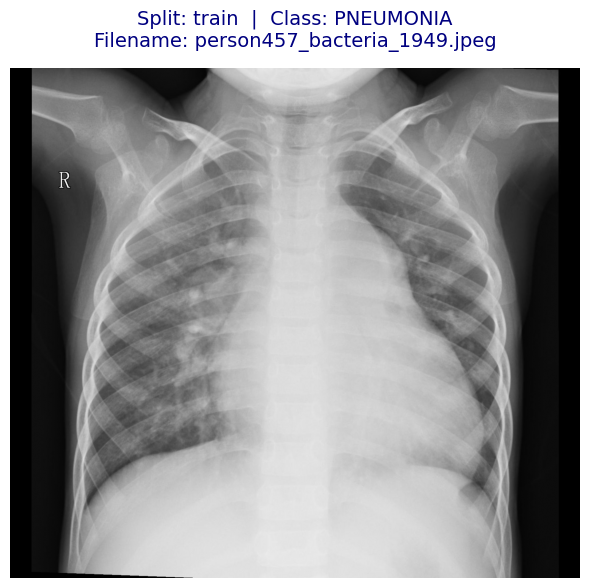

In [ ]:
# ============================================
# Cell 11: Display Sample Images
# ============================================
def show_one(split, cls, figsize=(6,6), cmap='gray'):
    p = os.path.join(base, split, cls)
    files = [f for f in os.listdir(p) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    if len(files) == 0:
        print(f"No images found in {p}")
        return
    fn = random.choice(files)
    img = Image.open(os.path.join(p, fn)).convert('L')
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap)
    plt.title(f"Split: {split}  |  Class: {cls}\nFilename: {fn}", fontsize=14, color='navy', pad=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

show_one("train", "NORMAL")
show_one("train", "PNEUMONIA")

In [14]:
# ============================================
# Cell 12: Rebalance Validation Set (Optional)
# ============================================
base_path = "/content/chest_xray"
classes = ["NORMAL", "PNEUMONIA"]

# إعادة ملفات الـ val القديمة إلى الـ train لتنظيف التوزيع (خطوة اختيارية لضمان عدم ضياع صور)
for cls in classes:
    val_src = os.path.join(base_path, "val", cls)
    train_dst = os.path.join(base_path, "train", cls)
    files = os.listdir(val_src)
    for f in files:
        shutil.move(os.path.join(val_src, f), os.path.join(train_dst, f))

# الآن نسحب 208 صورة لكل نوع من train إلى val بشكل عشوائي
for cls in classes:
    train_src = os.path.join(base_path, "train", cls)
    val_dst = os.path.join(base_path, "val", cls)
    os.makedirs(val_dst, exist_ok=True)

    all_files = [f for f in os.listdir(train_src) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    val_samples = random.sample(all_files, 208)

    for f in val_samples:
        shutil.move(os.path.join(train_src, f), os.path.join(val_dst, f))

print("✅  moved to Validation Set: 208 NORMAL, 208 PNEUMONIA")

✅  moved to Validation Set: 208 NORMAL, 208 PNEUMONIA


In [15]:
train_pneu_dir = os.path.join(base_path, "train", "PNEUMONIA")
pneu_files = [f for f in os.listdir(train_pneu_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# إذا كان العدد أكبر من 2000، نحذف الزائد عشوائياً
if len(pneu_files) > 2000:
    to_delete = random.sample(pneu_files, len(pneu_files) - 2000)
    for f in to_delete:
        os.remove(os.path.join(train_pneu_dir, f))

print(f"✅ PNEUMONIA has been reduced {len(os.listdir(train_pneu_dir))} صورة")

✅ PNEUMONIA has been reduced 2000 صورة


In [16]:
!kaggle datasets download -d tolgadincer/labeled-chest-xray-images -q
!unzip -q labeled-chest-xray-images.zip -d /content/new_xray_dataset


Dataset URL: https://www.kaggle.com/datasets/tolgadincer/labeled-chest-xray-images
License(s): other


In [17]:
import os

base_new = "/content/new_xray_dataset"

for root, dirs, files in os.walk(base_new):
    print(root)


/content/new_xray_dataset
/content/new_xray_dataset/chest_xray
/content/new_xray_dataset/chest_xray/test
/content/new_xray_dataset/chest_xray/test/NORMAL
/content/new_xray_dataset/chest_xray/test/PNEUMONIA
/content/new_xray_dataset/chest_xray/train
/content/new_xray_dataset/chest_xray/train/NORMAL
/content/new_xray_dataset/chest_xray/train/PNEUMONIA


In [18]:
source_normal_path = "/content/new_xray_dataset/chest_xray/train/NORMAL"
target_normal_path = "/content/chest_xray/train/NORMAL"


In [19]:
current_count = len([f for f in os.listdir(target_normal_path) if f.lower().endswith(('.png','.jpg','.jpeg'))])
print("Current NORMAL images:", current_count)


Current NORMAL images: 1141


In [20]:
import shutil
import random
from tqdm import tqdm

TARGET = 2000
needed = TARGET - current_count

print(f"Need to add {needed} NORMAL images")

source_images = [f for f in os.listdir(source_normal_path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
random.shuffle(source_images)

added = 0
for img in tqdm(source_images):
    if added >= needed:
        break

    src = os.path.join(source_normal_path, img)
    dst = os.path.join(target_normal_path, f"extra_normal_{added}.jpeg")

    shutil.copy(src, dst)
    added += 1

print("✅ Done adding NORMAL images")
print("Final NORMAL count:", len(os.listdir(target_normal_path)))


Need to add 859 NORMAL images


 64%|██████▎   | 859/1349 [00:01<00:00, 598.44it/s]

✅ Done adding NORMAL images
Final NORMAL count: 2000


In [21]:
import os

train_path = "/content/chest_xray/train"
val_path   = "/content/chest_xray/val"
test_path  = "/content/chest_xray/test"

def count_images(folder):
    return len([f for f in os.listdir(folder) if f.lower().endswith(('.png','.jpg','.jpeg'))])

print("📊 FINAL DATASET DISTRIBUTION\n")

print("🔹 TRAIN")
print("NORMAL:", count_images(os.path.join(train_path, "NORMAL")))
print("PNEUMONIA:", count_images(os.path.join(train_path, "PNEUMONIA")))

print("\n🔹 VALIDATION")
print("NORMAL:", count_images(os.path.join(val_path, "NORMAL")))
print("PNEUMONIA:", count_images(os.path.join(val_path, "PNEUMONIA")))

print("\n🔹 TEST")
print("NORMAL:", count_images(os.path.join(test_path, "NORMAL")))
print("PNEUMONIA:", count_images(os.path.join(test_path, "PNEUMONIA")))


📊 FINAL DATASET DISTRIBUTION

🔹 TRAIN
NORMAL: 2000
PNEUMONIA: 2000

🔹 VALIDATION
NORMAL: 208
PNEUMONIA: 208

🔹 TEST
NORMAL: 234
PNEUMONIA: 390


In [23]:
from PIL import Image, ImageEnhance, ImageFilter
import random

def medical_augmentation(img):
    # 1. Rotation خفيف (وضعية المريض)
    if random.random() < 0.5:
        img = img.rotate(random.uniform(-7, 7))

    # 2. Brightness (جودة جهاز الأشعة)
    if random.random() < 0.5:
        img = ImageEnhance.Brightness(img).enhance(
            random.uniform(0.9, 1.1)
        )

    # 3. Contrast (تمييز الأنسجة)
    if random.random() < 0.5:
        img = ImageEnhance.Contrast(img).enhance(
            random.uniform(0.9, 1.1)
        )

    # 4. Sharpen خفيف جدًا
    if random.random() < 0.3:
        img = img.filter(ImageFilter.SHARPEN)

    # 5. Flip أفقي (مسموح للـ CXR)
    if random.random() < 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    return img


In [24]:
import os
from tqdm import tqdm

train_path = "/content/chest_xray/train"
classes = ["NORMAL", "PNEUMONIA"]

for cls in classes:
    cls_path = os.path.join(train_path, cls)
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    print(f"Applying medical AGM on {cls} ({len(images)} images)")

    for img_name in tqdm(images):
        img_path = os.path.join(cls_path, img_name)

        img = Image.open(img_path).convert("L")
        aug_img = medical_augmentation(img)

        # overwrite نفس الصورة (no increase)
        aug_img.save(img_path)


Applying medical AGM on NORMAL (2000 images)


100%|██████████| 2000/2000 [01:11<00:00, 27.88it/s]


Applying medical AGM on PNEUMONIA (2000 images)


100%|██████████| 2000/2000 [00:25<00:00, 79.48it/s]


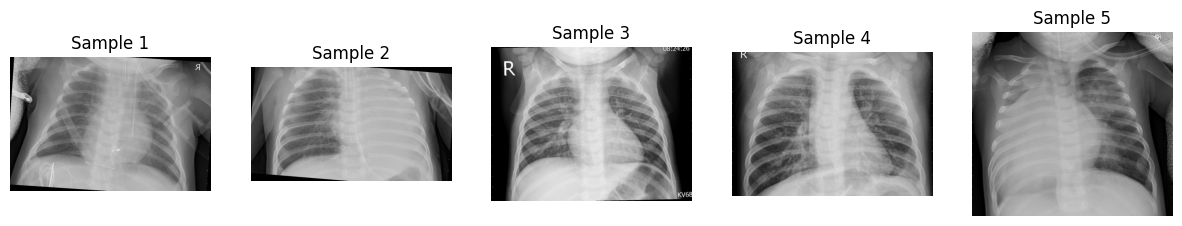

In [28]:
sample_path = "/content/chest_xray/train/PNEUMONIA"
images = os.listdir(sample_path)[:5]

plt.figure(figsize=(15,3))
for i, img_name in enumerate(images):
    img = Image.open(os.path.join(sample_path, img_name))
    plt.subplot(1,5,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Sample {i+1}")
    plt.axis("off")

plt.show()



In [29]:
# ============================================
# Cell 15: Load CLIP Model
# ============================================

device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model, preprocess = clip.load("ViT-B/32", device=device)


100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 62.2MiB/s]


In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

In [33]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets  # هذا السطر هو الحل للمشكلة

# إعداد البيانات مباشرة من المجلدات التي وازناها
train_dataset = datasets.ImageFolder("/content/chest_xray/train", transform=preprocess)
val_dataset   = datasets.ImageFolder("/content/chest_xray/val", transform=preprocess)
test_dataset  = datasets.ImageFolder("/content/chest_xray/test", transform=preprocess)

# Batch size 32 يعتبر متوازن للذاكرة في كولاب
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"✅ DataLoaders Ready:")
print(f"   - Train Samples: {len(train_dataset)}")
print(f"   - Val Samples:   {len(val_dataset)}")
print(f"   - Test Samples:  {len(test_dataset)}")

✅ DataLoaders Ready:
   - Train Samples: 4000
   - Val Samples:   416
   - Test Samples:  624


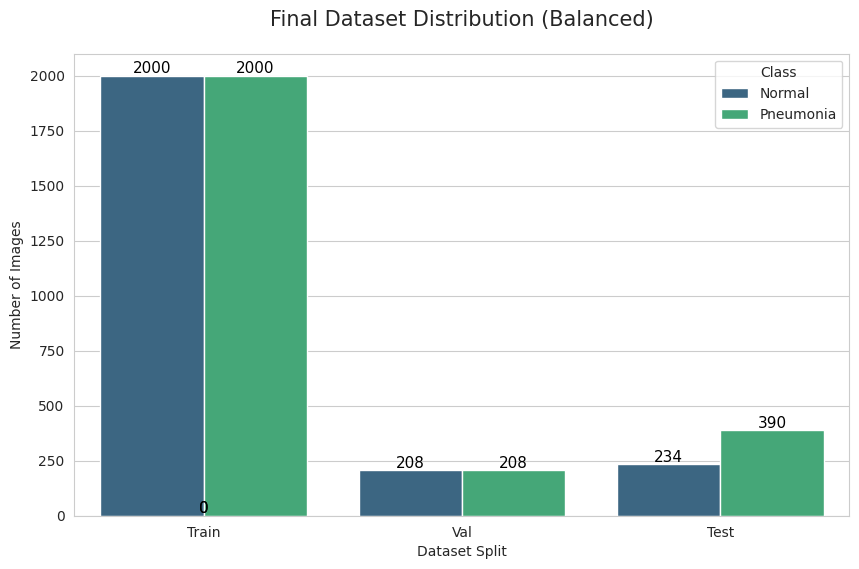

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. جمع البيانات للرسم
data = {
    'Split': ['Train', 'Train', 'Val', 'Val', 'Test', 'Test'],
    'Class': ['Normal', 'Pneumonia', 'Normal', 'Pneumonia', 'Normal', 'Pneumonia'],
    'Count': [
        len([1 for _, label in train_dataset.samples if label == 0]),
        len([1 for _, label in train_dataset.samples if label == 1]),
        len([1 for _, label in val_dataset.samples if label == 0]),
        len([1 for _, label in val_dataset.samples if label == 1]),
        len([1 for _, label in test_dataset.samples if label == 0]),
        len([1 for _, label in test_dataset.samples if label == 1])
    ]
}

df = pd.DataFrame(data)

# 2. رسم الأعمدة (Class Balance)
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='Split', y='Count', hue='Class', data=df, palette='viridis')

plt.title('Final Dataset Distribution (Balanced)', fontsize=15, pad=20)
plt.ylabel('Number of Images')
plt.xlabel('Dataset Split')

# إضافة الأرقام فوق الأعمدة
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

In [36]:
model = FullFineTunedModel(clip_model).to(device)
model.float() # <--- هذا السطر السحري يحل المشكلة

# 2. تعديل بسيط داخل دالة forward للتأكد من نوع المدخلات
class FullFineTunedModel(nn.Module):
    def __init__(self, clip_model_instance):
        super().__init__()
        self.clip_backbone = clip_model_instance.visual
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        # تحويل الصور لـ Float32 لتناسب أوزان الموديل بعد تحويله
        x = x.to(torch.float32)
        features = self.clip_backbone(x)
        return self.classifier(features)

# 3. عند تعريف الـ Optimizer، تأكد من إرسال الموديل للجهاز أولاً
model = FullFineTunedModel(clip_model).to(device)
model.float() # تحويل شامل لـ Float32
# فتح الأوزان للتدريب
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)
criterion = nn.CrossEntropyLoss()

# 3. إعداد متغيرات التتبع
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
patience = 5
patience_counter = 0
epochs = 20

print("🚀 Starting Clean Training Loop...")

# 4. حلقة التدريب
for epoch in range(epochs):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    # التحقق (Validation)
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    # الحسابات والنتائج
    epoch_train_loss = train_loss / len(train_loader)
    epoch_val_loss = val_loss / len(val_loader)
    epoch_train_acc = 100 * train_correct / train_total
    epoch_val_acc = 100 * val_correct / val_total

    scheduler.step(epoch_val_loss)

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    print(f"\n✅ Epoch {epoch+1}: Train Acc {epoch_train_acc:.2f}% | Val Acc {epoch_val_acc:.2f}%")
    print(f"   Loss: Train {epoch_train_loss:.4f} | Val {epoch_val_loss:.4f} | LR: {optimizer.param_groups[0]['lr']}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_medical_clip_model.pth")
        patience_counter = 0
        print("⭐ Model Saved!")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("🛑 Early Stopping!")
            break

🚀 Starting Clean Training Loop...


Epoch 1/20: 100%|██████████| 125/125 [02:31<00:00,  1.21s/it]



✅ Epoch 1: Train Acc 91.17% | Val Acc 92.07%
   Loss: Train 0.2659 | Val 0.2479 | LR: 1e-05
⭐ Model Saved!


Epoch 2/20: 100%|██████████| 125/125 [02:11<00:00,  1.05s/it]



✅ Epoch 2: Train Acc 97.15% | Val Acc 96.15%
   Loss: Train 0.1521 | Val 0.1292 | LR: 1e-05
⭐ Model Saved!


...


✅ Epoch 18: Train Acc 100.00% | Val Acc 98.32%
   Loss: Train 0.0238 | Val 0.0600 | LR: 1.0000000000000002e-07


Epoch 19/20: 100%|██████████| 125/125 [02:12<00:00,  1.06s/it]



✅ Epoch 19: Train Acc 100.00% | Val Acc 98.56%
   Loss: Train 0.0227 | Val 0.0603 | LR: 1.0000000000000002e-07


Epoch 20/20: 100%|██████████| 125/125 [02:12<00:00,  1.06s/it]



✅ Epoch 20: Train Acc 100.00% | Val Acc 98.32%
   Loss: Train 0.0249 | Val 0.0608 | LR: 1.0000000000000002e-07
🛑 Early Stopping!


In [32]:
import torch
from prettytable import PrettyTable

def get_model_summary(model, input_size=(1, 3, 224, 224)):
    table = PrettyTable(["Layer (type)", "Input Shape", "Output Shape", "Param #", "Trainable"])
    table.align = "l"

    total_params = 0
    trainable_params = 0

    # 1. استعراض الجزء الخاص بـ CLIP (Backbone)
    # نظراً لتعقيد CLIP، سنعرضه ككتلة واحدة (Block) لتجنب أخطاء التتبع
    clip_params = sum(p.numel() for p in model.clip_backbone.parameters())
    clip_trainable = any(p.requires_grad for p in model.clip_backbone.parameters())
    table.add_row(["CLIP Backbone (ViT-B/32)", "(3, 224, 224)", "(512)", f"{clip_params:,}", str(clip_trainable)])

    total_params += clip_params
    if clip_trainable: trainable_params += clip_params


    current_dim = 512

    for name, layer in model.classifier.named_children():
        layer_params = sum(p.numel() for p in layer.parameters())
        total_params += layer_params
        if any(p.requires_grad for p in layer.parameters()):
            trainable_params += layer_params

        # تحديد الأبعاد التقريبية لكل طبقة
        if isinstance(layer, torch.nn.Linear):
            out_dim = layer.out_features
            output_shape = f"({out_dim})"
            input_shape = f"({current_dim})"
            current_dim = out_dim
        else:
            output_shape = f"({current_dim})"
            input_shape = f"({current_dim})"

        table.add_row([f"  +-- {layer.__class__.__name__} ({name})", input_shape, output_shape, f"{layer_params:,}", "True"])

    print(table)
    print(f"\n🚀 Total Params: {total_params:,}")
    print(f"🔥 Trainable Params: {trainable_params:,}")
    print(f"❄️ Non-trainable Params: {total_params - trainable_params:,}")

# استدعاء الدالة للاستعراض
get_model_summary(model)

+--------------------------+---------------+--------------+------------+-----------+
| Layer (type)             | Input Shape   | Output Shape | Param #    | Trainable |
+--------------------------+---------------+--------------+------------+-----------+
| CLIP Backbone (ViT-B/32) | (3, 224, 224) | (512)        | 87,849,216 | True      |
|   +-- Linear (0)         | (512)         | (256)        | 131,328    | True      |
|   +-- BatchNorm1d (1)    | (256)         | (256)        | 512        | True      |
|   +-- ReLU (2)           | (256)         | (256)        | 0          | True      |
|   +-- Dropout (3)        | (256)         | (256)        | 0          | True      |
|   +-- Linear (4)         | (256)         | (128)        | 32,896     | True      |
|   +-- BatchNorm1d (5)    | (128)         | (128)        | 256        | True      |
|   +-- ReLU (6)           | (128)         | (128)        | 0          | True      |
|   +-- Dropout (7)        | (128)         | (128)        | 0    

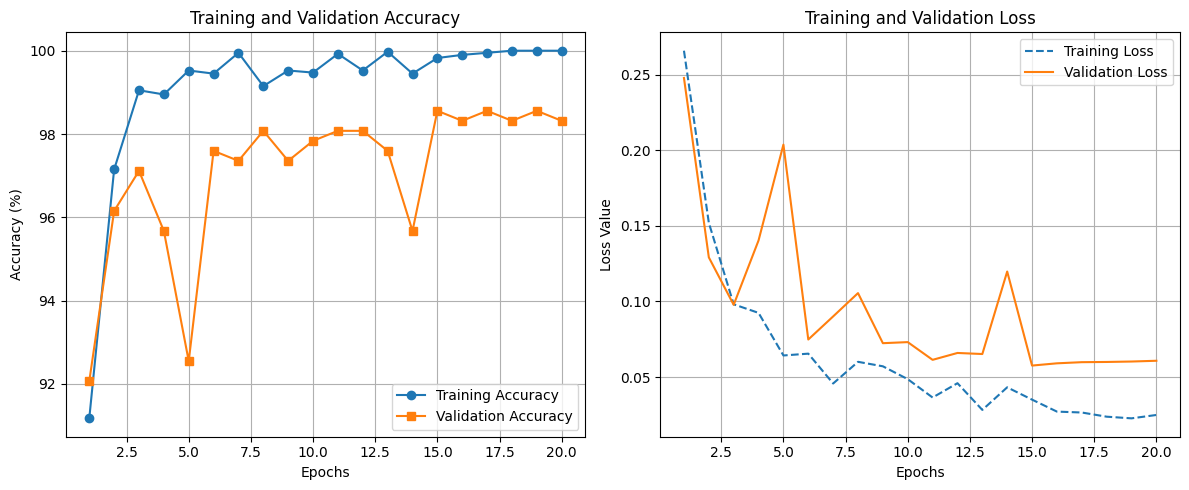

In [37]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # رسم الدقة (Accuracy)
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='s')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    # رسم الخسارة (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', linestyle='--')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='-')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# استدعاء الرسم بعد انتهاء التدريب
plot_history(history)

In [38]:
# 1. تحميل أفضل أوزان تم حفظها
model.load_state_dict(torch.load("best_medical_clip_model.pth"))
model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        test_correct += (outputs.argmax(1) == labels).sum().item()
        test_total += labels.size(0)

final_test_acc = 100 * test_correct / test_total
print(f"🚀 Final Accuracy on Test Set: {final_test_acc:.2f}%")

🚀 Final Accuracy on Test Set: 87.34%


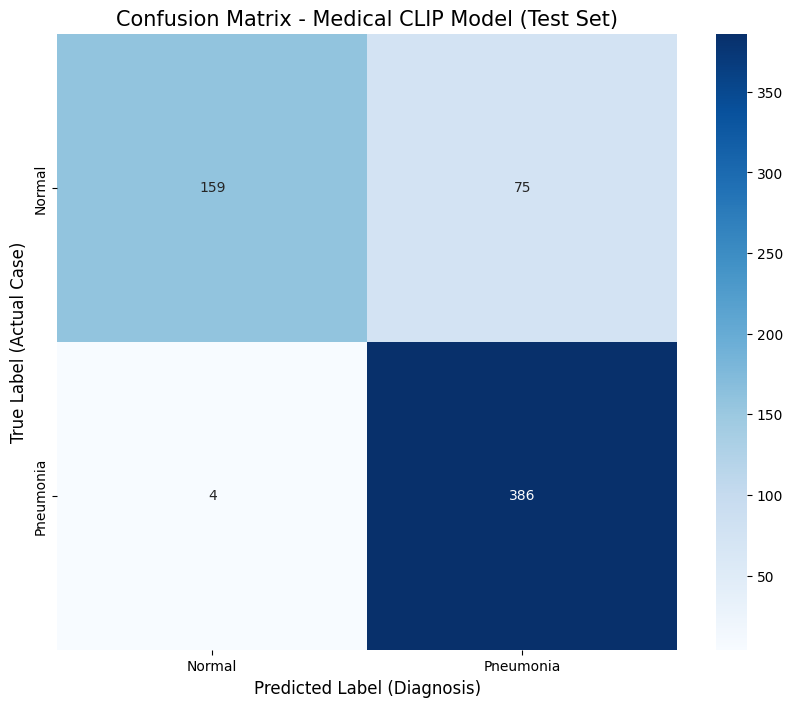


📊 Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.68      0.80       234
   Pneumonia       0.84      0.99      0.91       390

    accuracy                           0.87       624
   macro avg       0.91      0.83      0.85       624
weighted avg       0.89      0.87      0.87       624



In [40]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_final_confusion_matrix(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # حساب المصفوفة
    cm = confusion_matrix(y_true, y_pred)

    # الرسم الاحترافي
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Pneumonia'],
                yticklabels=['Normal', 'Pneumonia'])

    plt.title('Confusion Matrix - Medical CLIP Model (Test Set)', fontsize=15)
    plt.xlabel('Predicted Label (Diagnosis)', fontsize=12)
    plt.ylabel('True Label (Actual Case)', fontsize=12)
    plt.show()

    # طباعة التقرير الرقمي
    print("\n📊 Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

# استدعاء الدالة
plot_final_confusion_matrix(model, test_loader)

In [43]:
# ============================================
# Cell 26: Save Model
# ============================================
save_path = "/content/drive/MyDrive/best_chest_model_4.pth"
torch.save(model.state_dict(), save_path)
print("✅ Model saved to:", save_path)

✅ Model saved to: /content/drive/MyDrive/best_chest_model_4.pth


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [51]:
import os
files = [f for f in os.listdir('.') if f.endswith('.pth')]
print(f"الملفات المتاحة هي: {files}")

الملفات المتاحة هي: ['best_medical_clip_model.pth']


# ============================================
# **Cell: Live Demo  - Single Image Test**
# ============================================


100%|███████████████████████████████████████| 338M/338M [00:08<00:00, 40.9MiB/s]


✅ Model loaded successfully!


Saving N.jpg to N.jpg


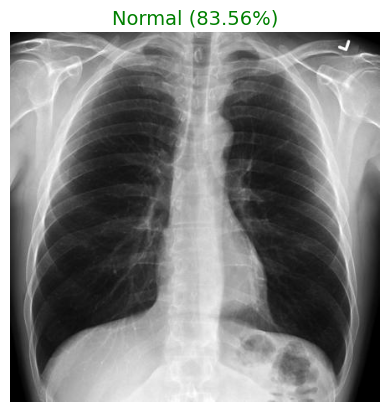

🎯 Diagnosis: Normal
📊 Confidence: 83.56%


In [4]:
# ============================================
# ✅ FINAL LIVE DEMO — FIXED (dtype issue solved)
# ============================================

import torch
import torch.nn as nn
import clip
from PIL import Image
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# نفس بنية الموديل المدرب
class FullFineTunedModel(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.clip_backbone = clip_model.visual
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        # ✨ نخلي نوع الصورة نفس نوع أوزان CLIP
        x = x.type(self.clip_backbone.conv1.weight.dtype)
        features = self.clip_backbone(x)
        return self.classifier(features)

# تحميل CLIP
clip_model, preprocess = clip.load("ViT-B/32", device=device)

# تحميل الموديل المدرب
model = FullFineTunedModel(clip_model).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/best_chest_model_4.pth", map_location=device))
model.eval()

print("✅ Model loaded successfully!")

# ============================================
# 🧪 Function: Diagnose Single Image
# ============================================
def diagnose_image(image_path):
    image = Image.open(image_path).convert("RGB")
    img_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]

    classes = ["Normal", "Pneumonia"]
    prediction = classes[probs.argmax()]
    confidence = probs.max() * 100

    plt.imshow(image)
    plt.title(f"{prediction} ({confidence:.2f}%)",
              color='red' if prediction=="Pneumonia" else 'green',
              fontsize=14)
    plt.axis("off")
    plt.show()

    print(f"🎯 Diagnosis: {prediction}")
    print(f"📊 Confidence: {confidence:.2f}%")

# ============================================
# 📤 Upload and Test Image
# ============================================
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

diagnose_image(img_path)


100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 80.3MiB/s]


✅ Model loaded successfully!


Saving images (2).jpg to images (2).jpg


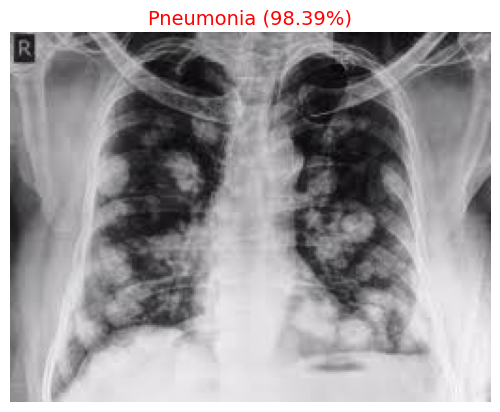

🎯 Diagnosis: Pneumonia
📊 Confidence: 98.39%


In [3]:
# ============================================
# ✅ FINAL LIVE DEMO — FIXED (dtype issue solved)
# ============================================

import torch
import torch.nn as nn
import clip
from PIL import Image
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# نفس بنية الموديل المدرب
class FullFineTunedModel(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.clip_backbone = clip_model.visual
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        # ✨ نخلي نوع الصورة نفس نوع أوزان CLIP
        x = x.type(self.clip_backbone.conv1.weight.dtype)
        features = self.clip_backbone(x)
        return self.classifier(features)

# تحميل CLIP
clip_model, preprocess = clip.load("ViT-B/32", device=device)

# تحميل الموديل المدرب
model = FullFineTunedModel(clip_model).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/best_chest_model_4.pth", map_location=device))
model.eval()

print("✅ Model loaded successfully!")

# ============================================
# 🧪 Function: Diagnose Single Image
# ============================================
def diagnose_image(image_path):
    image = Image.open(image_path).convert("RGB")
    img_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]

    classes = ["Normal", "Pneumonia"]
    prediction = classes[probs.argmax()]
    confidence = probs.max() * 100

    plt.imshow(image)
    plt.title(f"{prediction} ({confidence:.2f}%)",
              color='red' if prediction=="Pneumonia" else 'green',
              fontsize=14)
    plt.axis("off")
    plt.show()

    print(f"🎯 Diagnosis: {prediction}")
    print(f"📊 Confidence: {confidence:.2f}%")

# ============================================
# 📤 Upload and Test Image
# ============================================
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

diagnose_image(img_path)


In [4]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

llm_name = "google/flan-t5-base"  # أسرع وأخف من large
tokenizer = T5Tokenizer.from_pretrained(llm_name)
llm_model = T5ForConditionalGeneration.from_pretrained(llm_name).to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [13]:
from transformers import T5Tokenizer, T5ForConditionalGeneration
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "google/flan-t5-large"
tokenizer = T5Tokenizer.from_pretrained(model_name)
llm_model = T5ForConditionalGeneration.from_pretrained(model_name).to(device)


def generate_structured_report_llm(diagnosis, confidence):
    confidence = round(confidence * 100, 2)

    # Prompt يخلي LLM يكتب التقرير ضمن حدود واضحة
    prompt = f"""
You are an AI assistant generating a short educational chest X-ray report.

Diagnosis: {diagnosis}
Model confidence: {confidence}%

Write:
1) Findings (1–2 sentences explaining visual patterns)
2) Impression (1 short sentence explaining the AI decision)

Do NOT mention hospitals, doctors, or treatments.
Keep it simple and educational.
"""

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    outputs = llm_model.generate(
        **inputs,
        max_length=120,
        temperature=0.7,      # يعطي تنوع بسيط
        top_p=0.9,
        do_sample=True,
        repetition_penalty=1.1
    )

    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # محاولة تقسيم النص الناتج إلى Findings و Impression
    parts = generated_text.split("Impression:")
    if len(parts) == 2:
        findings = parts[0].replace("Findings:", "").strip()
        impression = parts[1].strip()
    else:
        # fallback إذا FLAN ما التزم بالتقسيم
        findings = generated_text.strip()
        impression = f"The AI model predicts {diagnosis.lower()} based on learned image features."

    report = f"""
CHEST X-RAY AI REPORT
---------------------------------

Diagnosis:
{diagnosis}

Model Confidence:
{confidence}%

Findings:
{findings}

Impression:
{impression}

Note:
This report was generated by an AI-assisted system for academic and research purposes only.
"""

    return report


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [14]:
def diagnose_and_report(image_path):
    image = Image.open(image_path).convert("RGB")
    img_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]

    classes = ["Normal", "Pneumonia"]
    prediction = classes[probs.argmax()]
    confidence = probs.max() * 100 # النسبة المئوية هنا

    # إنشاء التقرير
    report = generate_structured_report(prediction, confidence)

    # 🎨 عرض احترافي
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    plt.subplots_adjust(wspace=0.4) # مسافة بين الصورة والنص

    # عرض الصورة
    ax[0].imshow(image)
    color = 'red' if prediction == "Pneumonia" else 'green'
    ax[0].set_title(f"Result: {prediction}", color=color, fontsize=16, weight='bold')
    ax[0].axis("off")

    # عرض التقرير كـ Text
    ax[1].axis("off")
    # استخدام الخطوط الثابتة العرض لجعل التقرير يبدو منظماً
    ax[1].text(0, 0.5, report, fontsize=12, family='monospace',
               verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.2))

    plt.show()

    # طباعة التقرير الكامل في الكونسول
    print("\n" + "="*30)
    print(report)
    print("="*30)

Saving images (2).jpg to images (2) (4).jpg


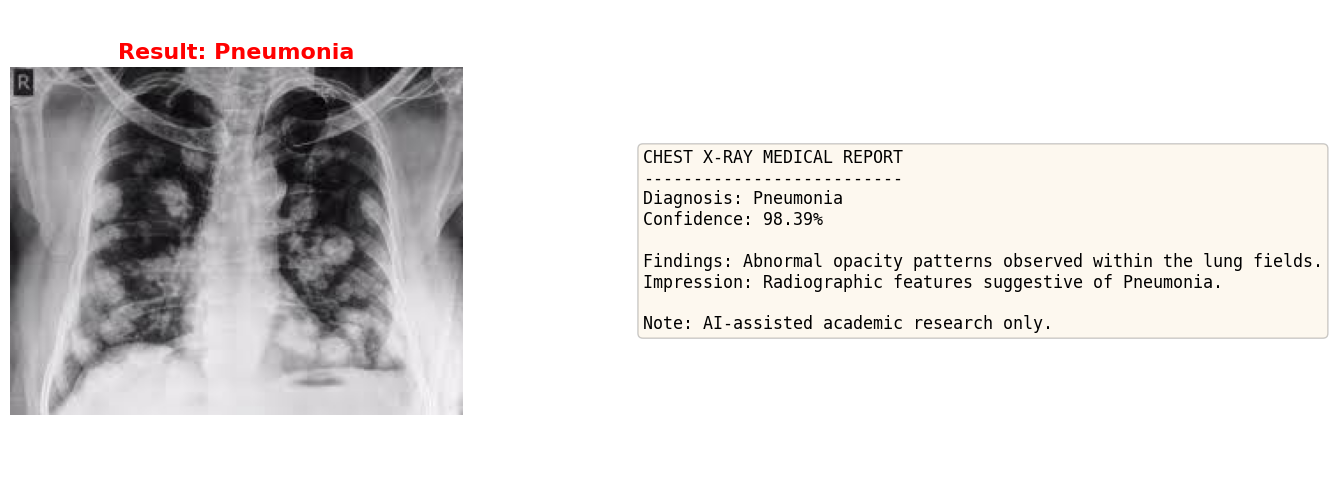


CHEST X-RAY MEDICAL REPORT
--------------------------
Diagnosis: Pneumonia
Confidence: 98.39%

Findings: Abnormal opacity patterns observed within the lung fields.
Impression: Radiographic features suggestive of Pneumonia.

Note: AI-assisted academic research only.


In [15]:
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

diagnose_and_report(img_path)


Saving N.jpg to N.jpg


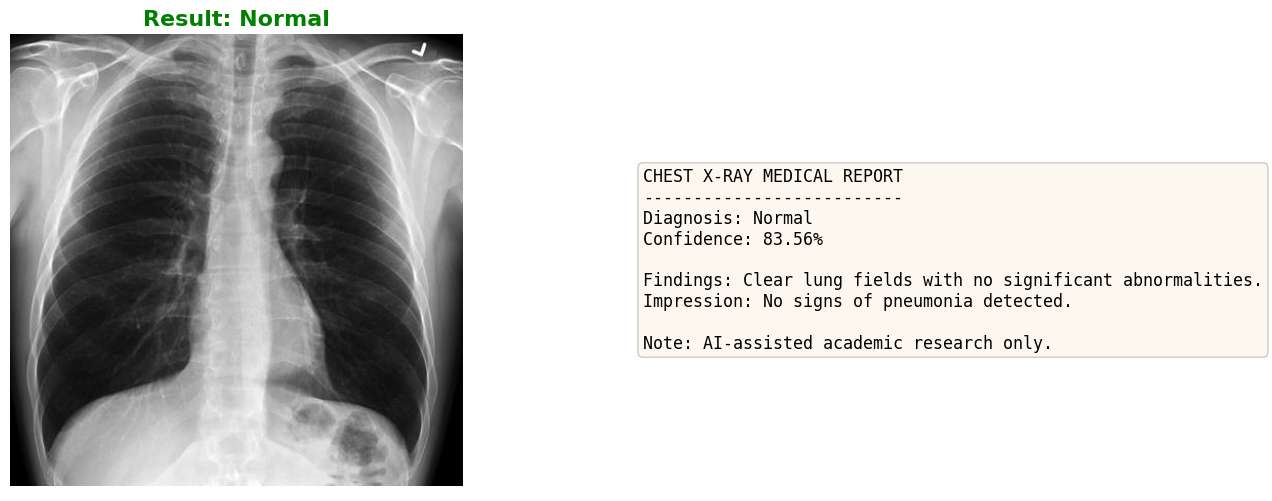


CHEST X-RAY MEDICAL REPORT
--------------------------
Diagnosis: Normal
Confidence: 83.56%

Findings: Clear lung fields with no significant abnormalities.
Impression: No signs of pneumonia detected.

Note: AI-assisted academic research only.


In [16]:
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

diagnose_and_report(img_path)
